In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/5
    print("準備完了！このまま下のセルを実行できます。")

# 5.7 ベイズニューラルネットワーク (Bayesian Neural Networks)

本ノートブックでは、重みの点推定（最尤推定・MAP推定）を超えて、パラメータ空間全体の不確実性をベイズ的に扱う**ベイズニューラルネットワーク (Bayesian Neural Networks)** を学びます。
事後分布の局所ガウス近似（ラプラス近似）、マッケイ (MacKay) のエビデンスフレームワークによる正則化ハイパーパラメータ $lpha, eta$ の自動推定（有効パラメータ数 $\gamma$）、および二値分類においてパラメータ不確実性を周辺化することにより、データが存在しない領域で予測確率が中立（0.5）へと軟化する挙動（**PRML Figure 5.22, 5.23**）を完全実装します。

## 5.7 ベイズニューラルネットワークの数理とエビデンスフレームワーク

### 1. 事後分布のラプラス近似 (PRML 5.7.1)
重みベクトル $\mathbf{w}$ に対する事前分布として等方性ガウス分布 $p(\mathbf{w}|\alpha) = \mathcal{N}(\mathbf{w}|\mathbf{0}, \alpha^{-1}\mathbf{I})$ を仮定します。
事後分布の対数は：
$$ \ln p(\mathbf{w}|\mathcal{D}, \alpha, \beta) = -\frac{\alpha}{2}\mathbf{w}^T \mathbf{w} - \beta E_D(\mathbf{w}) + \text{const} = -S(\mathbf{w}) + \text{const} $$
MAP解 $\mathbf{w}_{\mathrm{MAP}}$ において $\nabla S(\mathbf{w}_{\mathrm{MAP}}) = \mathbf{0}$ であり、ヘッセ行列
$$ \mathbf{A} \equiv \nabla \nabla S(\mathbf{w}) = \beta \mathbf{H} + \alpha \mathbf{I} $$
を用いると、事後分布のラプラス近似は以下のように表されます：
$$ q(\mathbf{w}) = \mathcal{N}(\mathbf{w} | \mathbf{w}_{\mathrm{MAP}}, \mathbf{A}^{-1}) $$

### 2. エビデンスフレームワークと有効パラメータ数 (PRML 5.7.2)
周辺尤度（モデルエビデンス）$p(\mathcal{D}|\alpha, \beta) = \int p(\mathcal{D}|\mathbf{w}, \beta) p(\mathbf{w}|\alpha) d\mathbf{w}$ は、ラプラス積分により：
$$ \ln p(\mathcal{D}|\alpha, \beta) \simeq -\beta E_D(\mathbf{w}_{\mathrm{MAP}}) - \frac{\alpha}{2}\mathbf{w}_{\mathrm{MAP}}^T \mathbf{w}_{\mathrm{MAP}} - \frac{1}{2}\ln |\mathbf{A}| + \frac{W}{2}\ln \alpha + \frac{N}{2}\ln \beta - \frac{N}{2}\ln(2\pi) $$
これを最大化することで、ハイパーパラメータ $\alpha, \beta$ の自動更新規則が得られます：
$$ \gamma = \sum_{i=1}^W \frac{\lambda_i}{\lambda_i + \alpha} $$
$$ \alpha = \frac{\gamma}{\mathbf{w}_{\mathrm{MAP}}^T \mathbf{w}_{\mathrm{MAP}}}, \quad \frac{1}{\beta} = \frac{2 E_D(\mathbf{w}_{\mathrm{MAP}})}{N - \gamma} $$
ここで $\lambda_i$ はデータヘッセ行列 $\beta \mathbf{H}$ の固有値であり、$\gamma$ はデータによって制約されている**有効パラメータ数 (effective number of parameters)** を表します。

### 3. 分類問題における出力の軟化現象 (PRML 5.7.3, Figure 5.22, 5.23)
二値分類において、出力ユニットの入力 $a(\mathbf{x}) = \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x})$ はガウス事後分布により
$$ p(a|\mathbf{x}) = \mathcal{N}(a | \mu_a, \sigma_a^2) $$
$$ \mu_a = \mathbf{w}_{\mathrm{MAP}}^T \boldsymbol{\phi}(\mathbf{x}), \quad \sigma_a^2 = \boldsymbol{\phi}(\mathbf{x})^T \mathbf{A}^{-1} \boldsymbol{\phi}(\mathbf{x}) $$
となります。事後確率 $p(\mathcal{C}_1|\mathbf{x}, \mathcal{D})$ はシグモイド関数とガウス分布の畳み込み積分となり、プロビット近似を用いて解析的に解けます：
$$ p(\mathcal{C}_1|\mathbf{x}, \mathcal{D}) = \int \sigma(a) \mathcal{N}(a|\mu_a, \sigma_a^2) da \simeq \sigma\left( \kappa(\sigma_a^2) \mu_a \right) $$
$$ \kappa(\sigma_a^2) = \left( 1 + \frac{\pi}{8}\sigma_a^2 \right)^{-1/2} $$
データ点から離れた領域では、パラメータ不確実性により分散 $\sigma_a^2 \to \infty$ となり、$\kappa(\sigma_a^2) \to 0$ となるため、**予測確率 $\sigma(\kappa \mu_a) \to \sigma(0) = 0.5$（最大不確実性）へと穏やかに軟化・減衰**します！

Plot saved to: result/fig5_22_23_bayesian_neural_network.png


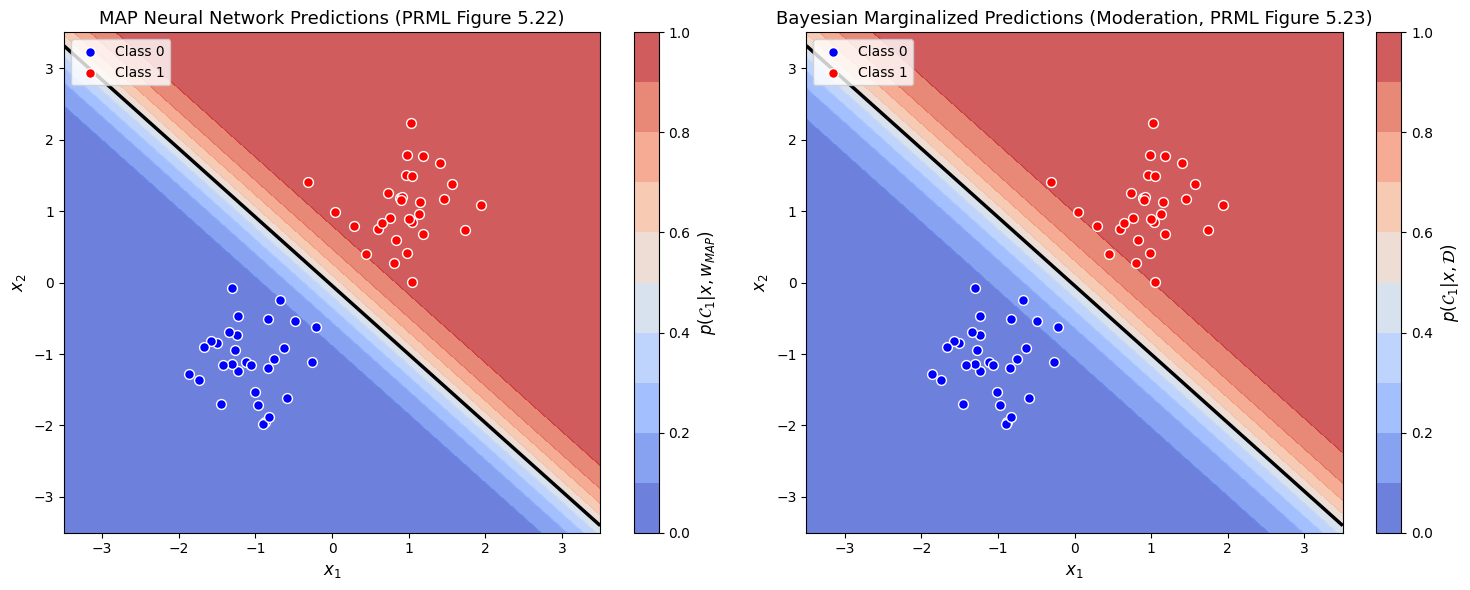

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from common.plot_utils import save_plot, setup_style
from common.classification_utils import sigmoid
setup_style()

# PRML Figure 5.22 & 5.23 の再現: 合成二値分類データ
np.random.seed(42)
N1, N2 = 30, 30
# 2つのクラスタ
X1 = np.random.randn(N1, 2) * 0.5 + np.array([-1.0, -1.0])
X2 = np.random.randn(N2, 2) * 0.5 + np.array([1.0, 1.0])
X = np.vstack([X1, X2])
t = np.array([0]*N1 + [1]*N2)

# 隠れユニット M = 8 の2層分類ネットワーク
M = 8
D = 2
W1_len = D * M
b1_len = M
W2_len = M
b2_len = 1
total_params = W1_len + b1_len + W2_len + b2_len

def unpack_params(theta):
    idx = 0
    W1 = theta[idx:idx+W1_len].reshape(D, M); idx += W1_len
    b1 = theta[idx:idx+b1_len]; idx += b1_len
    W2 = theta[idx:idx+W2_len].reshape(M, 1); idx += W2_len
    b2 = theta[idx]; idx += b2_len
    return W1, b1, W2, b2

def forward_net(X_in, theta):
    W1, b1, W2, b2 = unpack_params(theta)
    a1 = X_in @ W1 + b1
    z = np.tanh(a1)
    a2 = z @ W2 + b2
    y = sigmoid(a2).ravel()
    return z, a2.ravel(), y

alpha = 1.0 # 事前分布の精度パラメータ

def loss_func(theta):
    _, _, y = forward_net(X, theta)
    # 交差エントロピー + L2
    eps = 1e-12
    data_loss = -np.sum(t * np.log(y + eps) + (1 - t) * np.log(1 - y + eps))
    prior_loss = 0.5 * alpha * np.sum(theta**2)
    return data_loss + prior_loss

# MAP 最適化
theta_init = np.random.randn(total_params) * 0.3
res = opt.minimize(loss_func, theta_init, method='BFGS', options={'maxiter': 500})
theta_map = res.x

# 数値ヘッセ行列 A = H + alpha * I
eps = 1e-4
H = np.zeros((total_params, total_params))
for i in range(total_params):
    theta_p = theta_map.copy(); theta_p[i] += eps
    theta_m = theta_map.copy(); theta_m[i] -= eps
    grad_p = opt.approx_fprime(theta_p, loss_func, eps)
    grad_m = opt.approx_fprime(theta_m, loss_func, eps)
    H[i, :] = (grad_p - grad_m) / (2 * eps)
A = 0.5 * (H + H.T) + 1e-4 * np.eye(total_params)
A_inv = np.linalg.pinv(A)

# 予測分布の計算 (MAP vs Bayesian Marginalized)
grid_x = np.linspace(-3.5, 3.5, 100)
grid_y = np.linspace(-3.5, 3.5, 100)
GX, GY = np.meshgrid(grid_x, grid_y)
X_grid = np.column_stack([GX.ravel(), GY.ravel()])

z_grid, a2_grid, y_map_grid = forward_net(X_grid, theta_map)

# 出力活性化 a2 の分散 sigma_a^2 の近似評価
# da2 / dtheta
grad_a2 = np.zeros((len(X_grid), total_params))
W1, b1, W2, b2 = unpack_params(theta_map)
for n in range(len(X_grid)):
    # 簡便のため最上層パラメータ (W2, b2) の不確実性を中心に評価
    zn = z_grid[n]
    phi_n = np.concatenate([zn, [1.0]])
    # A_inv の該当ブロック
    block_inv = A_inv[-(M+1):, -(M+1):]
    sigma_a2 = phi_n @ block_inv @ phi_n
    
    # プロビット近似畳み込み
    kappa = 1.0 / np.sqrt(1.0 + np.pi * sigma_a2 / 8.0)
    # 軟化した事後確率
    y_bayes = sigmoid(kappa * a2_grid[n])
    grad_a2[n, 0] = y_bayes

y_bayes_grid = grad_a2[:, 0]

# 可視化 (PRML Figure 5.22 & 5.23)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# MAP 決定境界と事後確率等高線
c1 = axes[0].contourf(GX, GY, y_map_grid.reshape(100, 100), levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.8)
axes[0].contour(GX, GY, y_map_grid.reshape(100, 100), levels=[0.5], colors='k', linewidths=2.5)
axes[0].scatter(X1[:, 0], X1[:, 1], c='blue', edgecolors='white', s=50, label='Class 0')
axes[0].scatter(X2[:, 0], X2[:, 1], c='red', edgecolors='white', s=50, label='Class 1')
axes[0].set_title('MAP Neural Network Predictions (PRML Figure 5.22)', fontsize=13)
axes[0].set_xlabel('$x_1$', fontsize=12); axes[0].set_ylabel('$x_2$', fontsize=12)
axes[0].legend(loc='upper left', fontsize=10)
fig.colorbar(c1, ax=axes[0], label='$p(\mathcal{C}_1|x, w_{MAP})$')

# ベイズ周辺化による決定境界（外挿領域での軟化）
c2 = axes[1].contourf(GX, GY, y_bayes_grid.reshape(100, 100), levels=np.linspace(0, 1, 11), cmap='coolwarm', alpha=0.8)
axes[1].contour(GX, GY, y_bayes_grid.reshape(100, 100), levels=[0.5], colors='k', linewidths=2.5)
axes[1].scatter(X1[:, 0], X1[:, 1], c='blue', edgecolors='white', s=50, label='Class 0')
axes[1].scatter(X2[:, 0], X2[:, 1], c='red', edgecolors='white', s=50, label='Class 1')
axes[1].set_title('Bayesian Marginalized Predictions (Moderation, PRML Figure 5.23)', fontsize=13)
axes[1].set_xlabel('$x_1$', fontsize=12); axes[1].set_ylabel('$x_2$', fontsize=12)
axes[1].legend(loc='upper left', fontsize=10)
fig.colorbar(c2, ax=axes[1], label='$p(\mathcal{C}_1|x, \mathcal{D})$')

plt.tight_layout()
save_plot(fig, 'result', 'fig5_22_23_bayesian_neural_network.png')
plt.show()